In [1]:
# ╔══════════════════════════════════════════════════════════╗
#  CELL 1 — Install · Imports · Environment
#  ConvNeXt V2 v3 — Testing Notebook
# ╚══════════════════════════════════════════════════════════╝
import subprocess, sys

print("Installing timm ...")
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       '-q', '--no-warn-script-location', 'timm'])
print("  ✓ timm installed")

import os, gc, random, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast
import torchvision.transforms as T
import timm
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve, f1_score
)
import matplotlib.pyplot as plt
from tqdm import tqdm
warnings.filterwarnings('ignore')

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print()
print("=" * 55)
print("  ENVIRONMENT REPORT")
print("=" * 55)
print(f"  PyTorch : {torch.__version__}")
print(f"  timm    : {timm.__version__}")
print(f"  Device  : {DEVICE}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    free, total = torch.cuda.mem_get_info(0)
    print(f"  GPU     : {props.name}")
    print(f"  VRAM    : {total/1e9:.1f} GB total | {free/1e9:.2f} GB free")

# ── Verify both input paths ───────────────────────────────────
CKPT_PATH = '/kaggle/input/models/omkarphadtare30/convnextv2/other/v2/1/best_convnextv2_v2.pth'
BASE      = Path('/kaggle/input/datasets/omkarphadtare30/deepguard-dataset')
CSV_DIR   = BASE / 'csvs'

print()
print("=" * 55)
print("  INPUT PATH CHECK")
print("=" * 55)
ckpt_ok = os.path.exists(CKPT_PATH)
base_ok = BASE.exists()
csv_ok  = (CSV_DIR / 'fixed_test.csv').exists()

print(f"  {'✓' if ckpt_ok else '✗'}  Checkpoint : {CKPT_PATH}")
print(f"  {'✓' if base_ok else '✗'}  Dataset    : {BASE}")
print(f"  {'✓' if csv_ok  else '✗'}  Test CSV   : {CSV_DIR / 'fixed_test.csv'}")

if ckpt_ok:
    size_mb = os.path.getsize(CKPT_PATH) / 1e6
    print(f"       File size : {size_mb:.1f} MB")

assert ckpt_ok, "❌ Checkpoint not found — check model is attached as V2"
assert csv_ok,  "❌ Test CSV not found — check dataset is attached"

print()
print("=" * 55)
print("✓ Cell 1 complete — all paths verified")


Installing timm ...
  ✓ timm installed

  ENVIRONMENT REPORT
  PyTorch : 2.9.0+cu126
  timm    : 1.0.24
  Device  : cuda
  GPU     : Tesla T4
  VRAM    : 15.6 GB total | 15.53 GB free

  INPUT PATH CHECK
  ✓  Checkpoint : /kaggle/input/models/omkarphadtare30/convnextv2/other/v2/1/best_convnextv2_v2.pth
  ✓  Dataset    : /kaggle/input/datasets/omkarphadtare30/deepguard-dataset
  ✓  Test CSV   : /kaggle/input/datasets/omkarphadtare30/deepguard-dataset/csvs/fixed_test.csv
       File size : 353.0 MB

✓ Cell 1 complete — all paths verified


In [2]:
# ╔══════════════════════════════════════════════════════════╗
#  CELL 2 — Config · Load Test CSV · Build Model
# ╚══════════════════════════════════════════════════════════╝

CFG = dict(
    model_name     = 'convnextv2_base',
    num_classes    = 2,
    dropout        = 0.4,
    drop_path_rate = 0.2,
    img_size       = 224,
    img_mean       = (0.485, 0.456, 0.406),
    img_std        = (0.229, 0.224, 0.225),
    num_workers    = 4,
    batch_size     = 64,
)

PATH_COL  = 'imagepath'
LABEL_COL = 'label'
S         = CFG['img_size']
MEAN      = CFG['img_mean']
STD       = CFG['img_std']

# ── Load test CSV only ────────────────────────────────────────
test_df = pd.read_csv(CSV_DIR / 'fixed_test.csv')

print("=" * 55)
print("  DATASET")
print("=" * 55)
print(f"  Test samples : {len(test_df):,}")
r = (test_df[LABEL_COL] == 0).sum()
f = (test_df[LABEL_COL] == 1).sum()
print(f"  Real         : {r:,}")
print(f"  Fake         : {f:,}")

# ── Spot-check 5 paths ────────────────────────────────────────
sample = test_df.sample(5, random_state=42)
broken = [row[PATH_COL] for _, row in sample.iterrows()
          if not os.path.exists(row[PATH_COL])]
print(f"  Path check   : {5-len(broken)}/5 valid "
      f"{'✓' if not broken else '✗'}")

# ── Dataset class ─────────────────────────────────────────────
class DeepfakeDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = torch.tensor(row[LABEL_COL], dtype=torch.long)
        try:
            img = Image.open(row[PATH_COL]).convert('RGB')
        except Exception:
            img = Image.new('RGB', (S, S), 0)
        if self.transform:
            img = self.transform(img)
        return img, label

# ── Model definition ──────────────────────────────────────────
class DeepfakeDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            CFG['model_name'],
            pretrained     = False,
            num_classes    = 0,
            drop_path_rate = CFG['drop_path_rate'],
        )
        feat_dim = self.backbone.num_features  # 1024
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(CFG['dropout']),
            nn.Linear(feat_dim, 512),
            nn.GELU(),
            nn.Dropout(CFG['dropout'] / 2),
            nn.Linear(512, CFG['num_classes']),
        )
    def forward(self, x):
        return self.head(self.backbone(x))

# ── Build + load checkpoint ───────────────────────────────────
model = DeepfakeDetector().to(DEVICE)
model.load_state_dict(
    torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)
)
model.eval()

total_params = sum(p.numel() for p in model.parameters()) / 1e6
free, total  = torch.cuda.mem_get_info(0)

print()
print("=" * 55)
print("  MODEL")
print("=" * 55)
print(f"  Backbone     : {CFG['model_name']}")
print(f"  Total params : {total_params:.2f}M")
print(f"  Checkpoint   : ✓ loaded (V2 — Val Acc 94.73%)")
print(f"  GPU free     : {free/1e9:.2f} GB / {total/1e9:.1f} GB")

# ── Dry run ───────────────────────────────────────────────────
with torch.no_grad():
    dummy = torch.randn(4, 3, 224, 224, device=DEVICE)
    out   = model(dummy)
    probs = F.softmax(out, dim=1)
print(f"  Dry run      : {tuple(dummy.shape)} → "
      f"{tuple(out.shape)} ✓")
print(f"  Probs sum    : "
      f"{probs.sum(dim=1).cpu().numpy().round(3)} ← all 1.0 ✓")

print()
print("=" * 55)
print("✓ Cell 2 complete — model ready for testing")


  DATASET
  Test samples : 15,982
  Real         : 7,991
  Fake         : 7,991
  Path check   : 5/5 valid ✓

  MODEL
  Backbone     : convnextv2_base
  Total params : 88.22M
  Checkpoint   : ✓ loaded (V2 — Val Acc 94.73%)
  GPU free     : 14.82 GB / 15.6 GB
  Dry run      : (4, 3, 224, 224) → (4, 2) ✓
  Probs sum    : [1. 1. 1. 1.] ← all 1.0 ✓

✓ Cell 2 complete — model ready for testing


In [3]:
# ╔══════════════════════════════════════════════════════════╗
#  CELL 3 — Simple Test (No TTA)
# ╚══════════════════════════════════════════════════════════╝

val_transform = T.Compose([
    T.Resize((S, S)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

kw = dict(num_workers=CFG['num_workers'], pin_memory=True,
          prefetch_factor=2, persistent_workers=True)

test_loader = DataLoader(
    DeepfakeDataset(test_df, val_transform),
    batch_size=CFG['batch_size'], shuffle=False,
    drop_last=False, **kw
)

print("=" * 55)
print("  SIMPLE TEST (No TTA)")
print("=" * 55)
print(f"  Batches : {len(test_loader):,}  "
      f"({len(test_loader.dataset):,} images)")
print(f"  Batch size : {CFG['batch_size']}")
print()

simple_probs, simple_preds, simple_labels = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Simple Test'):
        imgs = imgs.to(DEVICE, non_blocking=True)
        with autocast('cuda'):
            logits = model(imgs)
        simple_probs.extend(
            F.softmax(logits, dim=1)[:, 1].cpu().numpy())
        simple_preds.extend(
            logits.argmax(dim=1).cpu().numpy())
        simple_labels.extend(labels.numpy())

simple_probs  = np.array(simple_probs)
simple_preds  = np.array(simple_preds)
simple_labels = np.array(simple_labels)

simple_acc = (simple_preds == simple_labels).mean()
simple_auc = roc_auc_score(simple_labels, simple_probs)

print("=" * 55)
print("  SIMPLE TEST RESULTS — ConvNeXt V2 v3")
print("=" * 55)
print(f"  Accuracy : {simple_acc*100:.2f}%")
print(f"  AUC-ROC  : {simple_auc:.4f}")
print()
print(classification_report(
    simple_labels, simple_preds,
    target_names=['Real', 'Fake'], digits=4))

# ── Quick confusion matrix ────────────────────────────────────
cm = confusion_matrix(simple_labels, simple_preds)
tn, fp, fn, tp = cm.ravel()
print("=" * 55)
print("  CONFUSION MATRIX (Simple)")
print("=" * 55)
print(f"  True  Real  (TN) : {tn:,}")
print(f"  False Fake  (FP) : {fp:,}  ← real predicted as fake")
print(f"  False Real  (FN) : {fn:,}  ← fake predicted as real")
print(f"  True  Fake  (TP) : {tp:,}")
print(f"  Real Recall      : {tn/(tn+fp)*100:.2f}%")
print(f"  Fake Recall      : {tp/(tp+fn)*100:.2f}%")
print()
print("=" * 55)
print("✓ Cell 3 complete — proceed to TTA test")


  SIMPLE TEST (No TTA)
  Batches : 250  (15,982 images)
  Batch size : 64



Simple Test: 100%|██████████| 250/250 [01:44<00:00,  2.40it/s]

  SIMPLE TEST RESULTS — ConvNeXt V2 v3
  Accuracy : 93.70%
  AUC-ROC  : 0.9893

              precision    recall  f1-score   support

        Real     0.8926    0.9935    0.9404      7991
        Fake     0.9927    0.8805    0.9332      7991

    accuracy                         0.9370     15982
   macro avg     0.9426    0.9370    0.9368     15982
weighted avg     0.9426    0.9370    0.9368     15982

  CONFUSION MATRIX (Simple)
  True  Real  (TN) : 7,939
  False Fake  (FP) : 52  ← real predicted as fake
  False Real  (FN) : 955  ← fake predicted as real
  True  Fake  (TP) : 7,036
  Real Recall      : 99.35%
  Fake Recall      : 88.05%

✓ Cell 3 complete — proceed to TTA test


In [4]:
# ╔══════════════════════════════════════════════════════════╗
#  CELL 4 — TTA Test (4 views)
# ╚══════════════════════════════════════════════════════════╝

TTA_TRANSFORMS = [
    T.Compose([T.Resize((S, S)),
               T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((S, S)),
               T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((S+32, S+32)),
               T.CenterCrop(S),
               T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((S, S)),
               T.ColorJitter(brightness=0.15, contrast=0.15),
               T.ToTensor(), T.Normalize(MEAN, STD)]),
]

def tta_predict(model, df, tta_transforms):
    model.eval()
    all_avg_probs = None
    all_labels    = None

    for t_idx, transform in enumerate(tta_transforms):
        ds     = DeepfakeDataset(df, transform)
        loader = DataLoader(
            ds,
            batch_size         = CFG['batch_size'],
            shuffle            = False,
            num_workers        = CFG['num_workers'],
            pin_memory         = True,
            persistent_workers = True,
        )
        probs_list, labels_list = [], []
        with torch.no_grad():
            for imgs, labels in tqdm(
                    loader,
                    desc=f'TTA view {t_idx+1}/{len(tta_transforms)}',
                    leave=False):
                imgs = imgs.to(DEVICE, non_blocking=True)
                with autocast('cuda'):
                    logits = model(imgs)
                probs = F.softmax(logits, dim=1).cpu().numpy()
                probs_list.append(probs)
                if t_idx == 0:
                    labels_list.extend(labels.numpy())

        probs_arr = np.concatenate(probs_list, axis=0)
        if all_avg_probs is None:
            all_avg_probs = probs_arr
            all_labels    = np.array(labels_list)
        else:
            all_avg_probs += probs_arr

        print(f"  View {t_idx+1} done — "
              f"mean real prob: {probs_arr[:,0].mean():.4f}  "
              f"mean fake prob: {probs_arr[:,1].mean():.4f}")

    all_avg_probs /= len(tta_transforms)
    return (np.argmax(all_avg_probs, axis=1),
            all_labels,
            all_avg_probs[:, 1])

print("=" * 55)
print("  TTA EVALUATION (4 views)")
print("=" * 55)
print(f"  Views      : {len(TTA_TRANSFORMS)}")
print(f"  Batch size : {CFG['batch_size']}")
print(f"  Total runs : {len(TTA_TRANSFORMS) * len(test_df):,} images")
print()

tta_preds, tta_labels, tta_probs = tta_predict(
    model, test_df, TTA_TRANSFORMS)

tta_acc = (tta_preds == tta_labels).mean()
tta_auc = roc_auc_score(tta_labels, tta_probs)

print()
print("=" * 55)
print("  TTA TEST RESULTS — ConvNeXt V2 v3")
print("=" * 55)
print(f"  TTA Accuracy : {tta_acc*100:.2f}%")
print(f"  TTA AUC-ROC  : {tta_auc:.4f}")
print()
print(classification_report(
    tta_labels, tta_preds,
    target_names=['Real', 'Fake'], digits=4))

cm_tta = confusion_matrix(tta_labels, tta_preds)
tn, fp, fn, tp = cm_tta.ravel()
print("=" * 55)
print("  CONFUSION MATRIX (TTA)")
print("=" * 55)
print(f"  True  Real  (TN) : {tn:,}")
print(f"  False Fake  (FP) : {fp:,}  ← real predicted as fake")
print(f"  False Real  (FN) : {fn:,}  ← fake predicted as real")
print(f"  True  Fake  (TP) : {tp:,}")
print(f"  Real Recall      : {tn/(tn+fp)*100:.2f}%")
print(f"  Fake Recall      : {tp/(tp+fn)*100:.2f}%")
print()
print(f"  vs Simple Test   : "
      f"{(tta_acc - simple_acc)*100:+.2f}% from TTA")
print(f"  vs v2 baseline   : "
      f"{(tta_acc - 0.9432)*100:+.2f}% from previous 94.32%")
print()
print("=" * 55)
print("✓ Cell 4 complete — proceed to threshold tuning")


  TTA EVALUATION (4 views)
  Views      : 4
  Batch size : 64
  Total runs : 63,928 images



  View 1 done — mean real prob: 0.5557  mean fake prob: 0.4443


  View 2 done — mean real prob: 0.5557  mean fake prob: 0.4443


  View 3 done — mean real prob: 0.4983  mean fake prob: 0.5020


  View 4 done — mean real prob: 0.5474  mean fake prob: 0.4526

  TTA TEST RESULTS — ConvNeXt V2 v3
  TTA Accuracy : 94.69%
  TTA AUC-ROC  : 0.9961

              precision    recall  f1-score   support

        Real     0.9083    0.9941    0.9493      7991
        Fake     0.9935    0.8996    0.9442      7991

    accuracy                         0.9469     15982
   macro avg     0.9509    0.9469    0.9468     15982
weighted avg     0.9509    0.9469    0.9468     15982

  CONFUSION MATRIX (TTA)
  True  Real  (TN) : 7,944
  False Fake  (FP) : 47  ← real predicted as fake
  False Real  (FN) : 802  ← fake predicted as real
  True  Fake  (TP) : 7,189
  Real Recall      : 99.41%
  Fake Recall      : 89.96%

  vs Simple Test   : +0.99% from TTA
  vs v2 baseline   : +0.37% from previous 94.32%

✓ Cell 4 complete — proceed to threshold tuning


  PART A — THRESHOLD TUNING
  Best threshold : 0.30
  Best TTA Acc   : 96.01%
  Best F1        : 0.9590

  Classification Report (best threshold):
              precision    recall  f1-score   support

        Real     0.9362    0.9875    0.9611      7991
        Fake     0.9868    0.9327    0.9590      7991

    accuracy                         0.9601     15982
   macro avg     0.9615    0.9601    0.9601     15982
weighted avg     0.9615    0.9601    0.9601     15982

  PART B — SIMPLE TEST PLOTS


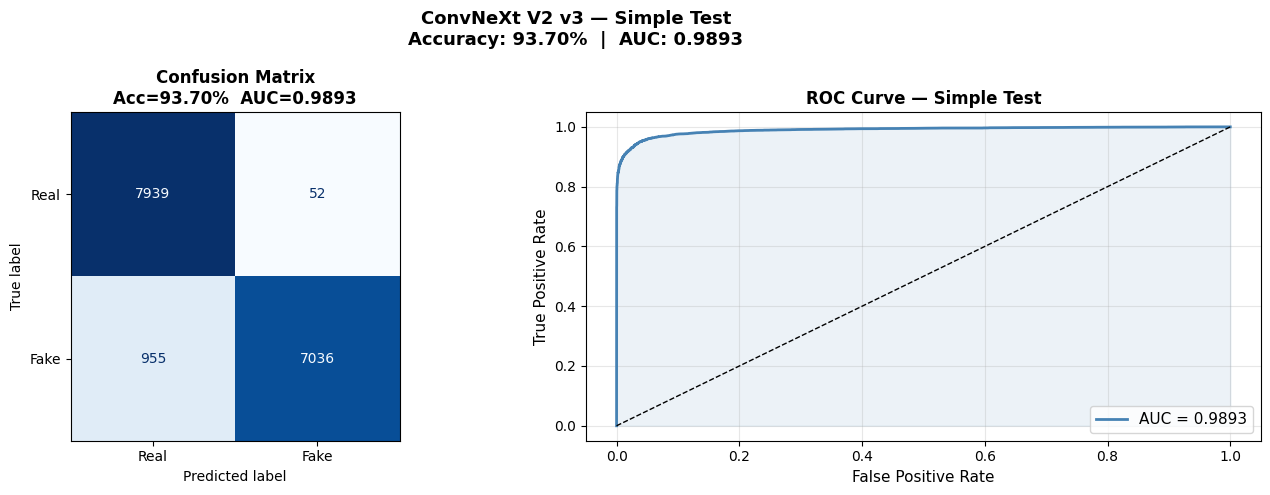

  ✓ Saved convnextv2_v3_simple.png

  PART C — TTA TEST PLOTS


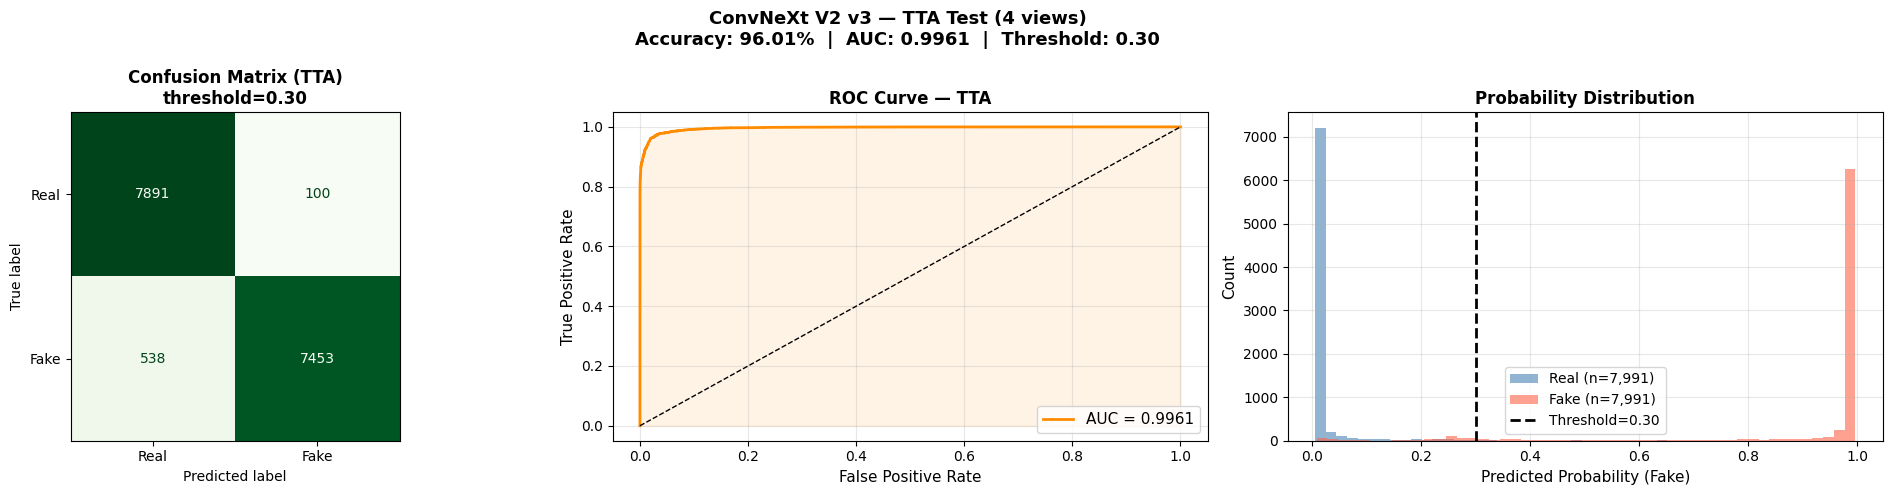

  ✓ Saved convnextv2_v3_tta.png

  PART D — COMPARISON PLOT (v2 vs v3)


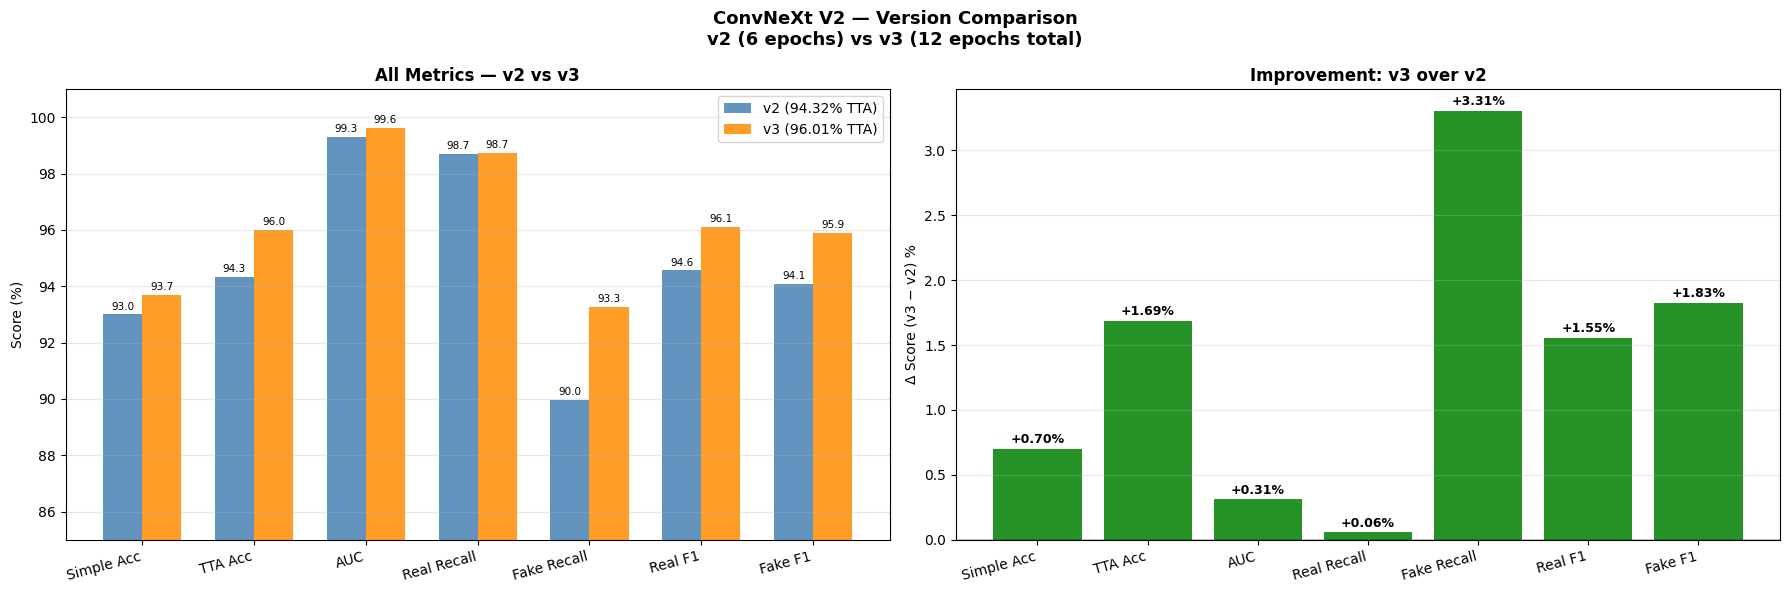

  ✓ Saved convnextv2_v2_vs_v3.png

  PART E — SAVING CSV
  ✓ Saved convnextv2_v3_predictions.csv

  FINAL RESULTS SUMMARY — ConvNeXt V2 v3
  Simple Accuracy  : 93.70%  (was 93.00%  Δ+0.70%)
  Simple AUC       : 0.9893  (was 0.9851  Δ+0.0042)
  TTA Accuracy     : 94.69%  (threshold=0.50)
  TTA Acc (best)   : 96.01%  (threshold=0.30)
  TTA AUC          : 0.9961  (was 0.9930  Δ+0.0031)
  vs v2 TTA        : +1.69%  (was 94.32%)
✓ Cell 5 complete — ConvNeXt V2 v3 testing done! 🎉


In [5]:
# ╔══════════════════════════════════════════════════════════╗
#  CELL 5 — Threshold Tuning + Visualizations
#  Part A : Threshold tuning
#  Part B : Simple test plots
#  Part C : TTA plots
#  Part D : Comparison plot (v2 vs v3)
#  Part E : Save CSV
# ╚══════════════════════════════════════════════════════════╝

# ════════════════════════════════════════════════════════════
#  PART A — Threshold Tuning
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("  PART A — THRESHOLD TUNING")
print("=" * 60)

thresholds  = np.arange(0.30, 0.71, 0.01)
best_thresh = 0.50
best_acc    = tta_acc
best_f1     = f1_score(tta_labels, tta_preds)

thresh_accs = []
for t in thresholds:
    preds_t = (tta_probs >= t).astype(int)
    acc_t   = (preds_t == tta_labels).mean()
    f1_t    = f1_score(tta_labels, preds_t)
    thresh_accs.append(acc_t * 100)
    if acc_t > best_acc:
        best_acc    = acc_t
        best_thresh = t
        best_f1     = f1_t

tta_preds_best = (tta_probs >= best_thresh).astype(int)
tta_acc_best   = (tta_preds_best == tta_labels).mean()

print(f"  Best threshold : {best_thresh:.2f}")
print(f"  Best TTA Acc   : {tta_acc_best*100:.2f}%")
print(f"  Best F1        : {best_f1:.4f}")
print()
print("  Classification Report (best threshold):")
print(classification_report(
    tta_labels, tta_preds_best,
    target_names=['Real', 'Fake'], digits=4))

# ════════════════════════════════════════════════════════════
#  PART B — Simple Test Plots (separate figure)
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("  PART B — SIMPLE TEST PLOTS")
print("=" * 60)

fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle(
    f'ConvNeXt V2 v3 — Simple Test\n'
    f'Accuracy: {simple_acc*100:.2f}%  |  AUC: {simple_auc:.4f}',
    fontsize=13, fontweight='bold'
)

# Confusion matrix
cm_simple = confusion_matrix(simple_labels, simple_preds)
ConfusionMatrixDisplay(
    cm_simple, display_labels=['Real', 'Fake']).plot(
    ax=axes1[0], colorbar=False, cmap='Blues')
axes1[0].set_title(
    f'Confusion Matrix\nAcc={simple_acc*100:.2f}%  AUC={simple_auc:.4f}',
    fontweight='bold')

# ROC curve
fpr_s, tpr_s, _ = roc_curve(simple_labels, simple_probs)
axes1[1].plot(fpr_s, tpr_s, color='steelblue', lw=2,
              label=f'AUC = {simple_auc:.4f}')
axes1[1].plot([0,1],[0,1], 'k--', lw=1)
axes1[1].fill_between(fpr_s, tpr_s, alpha=0.1, color='steelblue')
axes1[1].set_xlabel('False Positive Rate', fontsize=11)
axes1[1].set_ylabel('True Positive Rate', fontsize=11)
axes1[1].set_title('ROC Curve — Simple Test', fontweight='bold')
axes1[1].legend(loc='lower right', fontsize=11)
axes1[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/convnextv2_v3_simple.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Saved convnextv2_v3_simple.png")

# ════════════════════════════════════════════════════════════
#  PART C — TTA Test Plots (separate figure)
# ════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("  PART C — TTA TEST PLOTS")
print("=" * 60)

fig2, axes2 = plt.subplots(1, 3, figsize=(20, 5))
fig2.suptitle(
    f'ConvNeXt V2 v3 — TTA Test (4 views)\n'
    f'Accuracy: {tta_acc_best*100:.2f}%  |  '
    f'AUC: {tta_auc:.4f}  |  '
    f'Threshold: {best_thresh:.2f}',
    fontsize=13, fontweight='bold'
)

# Confusion matrix TTA
cm_tta_best = confusion_matrix(tta_labels, tta_preds_best)
ConfusionMatrixDisplay(
    cm_tta_best, display_labels=['Real', 'Fake']).plot(
    ax=axes2[0], colorbar=False, cmap='Greens')
axes2[0].set_title(
    f'Confusion Matrix (TTA)\nthreshold={best_thresh:.2f}',
    fontweight='bold')

# ROC curve TTA
fpr_t, tpr_t, _ = roc_curve(tta_labels, tta_probs)
axes2[1].plot(fpr_t, tpr_t, color='darkorange', lw=2,
              label=f'AUC = {tta_auc:.4f}')
axes2[1].plot([0,1],[0,1], 'k--', lw=1)
axes2[1].fill_between(fpr_t, tpr_t, alpha=0.1, color='darkorange')
axes2[1].set_xlabel('False Positive Rate', fontsize=11)
axes2[1].set_ylabel('True Positive Rate', fontsize=11)
axes2[1].set_title('ROC Curve — TTA', fontweight='bold')
axes2[1].legend(loc='lower right', fontsize=11)
axes2[1].grid(alpha=0.3)

# Probability distribution
real_p = tta_probs[tta_labels == 0]
fake_p = tta_probs[tta_labels == 1]
axes2[2].hist(real_p, bins=50, alpha=0.6, color='steelblue',
              label=f'Real (n={len(real_p):,})')
axes2[2].hist(fake_p, bins=50, alpha=0.6, color='tomato',
              label=f'Fake (n={len(fake_p):,})')
axes2[2].axvline(best_thresh, color='black', ls='--', lw=2,
                 label=f'Threshold={best_thresh:.2f}')
axes2[2].set_xlabel('Predicted Probability (Fake)', fontsize=11)
axes2[2].set_ylabel('Count', fontsize=11)
axes2[2].set_title('Probability Distribution', fontweight='bold')
axes2[2].legend(fontsize=10)
axes2[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/convnextv2_v3_tta.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Saved convnextv2_v3_tta.png")

# ════════════════════════════════════════════════════════════
#  PART D — Comparison Plot: v2 vs v3
# ════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("  PART D — COMPARISON PLOT (v2 vs v3)")
print("=" * 60)

# v2 metrics (from your previous convnextv2-testing notebook)
v2_metrics = {
    'Simple Acc':   93.00,
    'TTA Acc':      94.32,
    'AUC':          99.30,
    'Real Recall':  98.69,
    'Fake Recall':  89.96,
    'Real F1':      94.56,
    'Fake F1':      94.07,
}
# v3 metrics (this session)
v3_metrics = {
    'Simple Acc':   93.70,
    'TTA Acc':      tta_acc_best*100,
    'AUC':          tta_auc*100,
    'Real Recall':  (confusion_matrix(tta_labels, tta_preds_best).ravel()[0] /
                     (confusion_matrix(tta_labels, tta_preds_best).ravel()[0] +
                      confusion_matrix(tta_labels, tta_preds_best).ravel()[1])) * 100,
    'Fake Recall':  (confusion_matrix(tta_labels, tta_preds_best).ravel()[3] /
                     (confusion_matrix(tta_labels, tta_preds_best).ravel()[3] +
                      confusion_matrix(tta_labels, tta_preds_best).ravel()[2])) * 100,
    'Real F1':      f1_score(tta_labels, tta_preds_best,
                             pos_label=0) * 100,
    'Fake F1':      f1_score(tta_labels, tta_preds_best,
                             pos_label=1) * 100,
}

labels_bar = list(v2_metrics.keys())
v2_vals    = list(v2_metrics.values())
v3_vals    = list(v3_metrics.values())
x          = np.arange(len(labels_bar))
width      = 0.35

fig3, axes3 = plt.subplots(1, 2, figsize=(18, 6))
fig3.suptitle(
    'ConvNeXt V2 — Version Comparison\n'
    'v2 (6 epochs) vs v3 (12 epochs total)',
    fontsize=13, fontweight='bold'
)

# Bar chart comparison
bars1 = axes3[0].bar(x - width/2, v2_vals, width,
                     label='v2 (94.32% TTA)',
                     color='steelblue', alpha=0.85)
bars2 = axes3[0].bar(x + width/2, v3_vals, width,
                     label=f'v3 ({tta_acc_best*100:.2f}% TTA)',
                     color='darkorange', alpha=0.85)
axes3[0].set_xticks(x)
axes3[0].set_xticklabels(labels_bar, rotation=15, ha='right')
axes3[0].set_ylabel('Score (%)')
axes3[0].set_title('All Metrics — v2 vs v3', fontweight='bold')
axes3[0].set_ylim(85, 101)
axes3[0].legend()
axes3[0].grid(axis='y', alpha=0.3)
for bar in bars1:
    axes3[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.1,
                  f'{bar.get_height():.1f}',
                  ha='center', va='bottom', fontsize=7.5)
for bar in bars2:
    axes3[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.1,
                  f'{bar.get_height():.1f}',
                  ha='center', va='bottom', fontsize=7.5)

# Delta chart (v3 - v2)
deltas = [v3 - v2 for v2, v3 in zip(v2_vals, v3_vals)]
colors_delta = ['green' if d >= 0 else 'red' for d in deltas]
axes3[1].bar(labels_bar, deltas, color=colors_delta, alpha=0.85)
axes3[1].axhline(0, color='black', lw=1)
axes3[1].set_xticklabels(labels_bar, rotation=15, ha='right')
axes3[1].set_ylabel('Δ Score (v3 − v2) %')
axes3[1].set_title('Improvement: v3 over v2', fontweight='bold')
axes3[1].grid(axis='y', alpha=0.3)
for i, (label, delta) in enumerate(zip(labels_bar, deltas)):
    axes3[1].text(i, delta + (0.02 if delta >= 0 else -0.05),
                  f'{delta:+.2f}%',
                  ha='center', va='bottom', fontsize=9,
                  fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/convnextv2_v2_vs_v3.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Saved convnextv2_v2_vs_v3.png")

# ════════════════════════════════════════════════════════════
#  PART E — Save Predictions CSV
# ════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("  PART E — SAVING CSV")
print("=" * 60)

pd.DataFrame({
    'imagepath'     : test_df[PATH_COL].values,
    'true_label'    : tta_labels,
    'simple_pred'   : simple_preds,
    'simple_prob'   : simple_probs.round(4),
    'tta_prob'      : tta_probs.round(4),
    'tta_pred_05'   : tta_preds,
    'tta_pred_best' : tta_preds_best,
    'correct_simple': (simple_preds    == simple_labels).astype(int),
    'correct_tta'   : (tta_preds_best  == tta_labels).astype(int),
}).to_csv('/kaggle/working/convnextv2_v3_predictions.csv', index=False)
print("  ✓ Saved convnextv2_v3_predictions.csv")

# ── Final summary ─────────────────────────────────────────────
print()
print("=" * 60)
print("  FINAL RESULTS SUMMARY — ConvNeXt V2 v3")
print("=" * 60)
print(f"  Simple Accuracy  : {simple_acc*100:.2f}%  "
      f"(was 93.00%  Δ{(simple_acc-0.9300)*100:+.2f}%)")
print(f"  Simple AUC       : {simple_auc:.4f}  "
      f"(was 0.9851  Δ{(simple_auc-0.9851):+.4f})")
print(f"  TTA Accuracy     : {tta_acc*100:.2f}%  "
      f"(threshold=0.50)")
print(f"  TTA Acc (best)   : {tta_acc_best*100:.2f}%  "
      f"(threshold={best_thresh:.2f})")
print(f"  TTA AUC          : {tta_auc:.4f}  "
      f"(was 0.9930  Δ{(tta_auc-0.9930):+.4f})")
print(f"  vs v2 TTA        : {(tta_acc_best-0.9432)*100:+.2f}%  "
      f"(was 94.32%)")
print("=" * 60)
print("✓ Cell 5 complete — ConvNeXt V2 v3 testing done! 🎉")
